<a href="https://colab.research.google.com/github/Yuliana-Lestari/data-science-2026/blob/main/Pertemuan13_YulianaLestari_250401020199.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install tensorflow -q

In [13]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

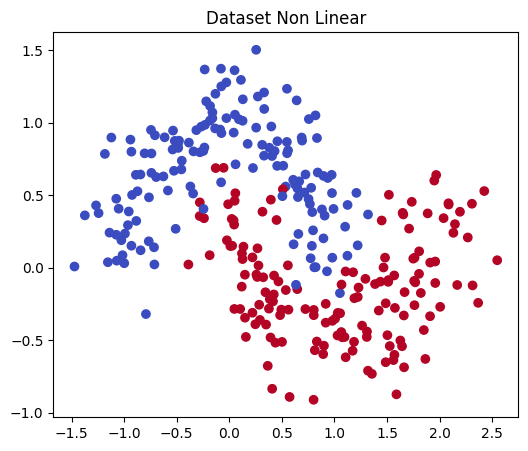

In [14]:
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.figure(figsize=(6,5))
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Dataset Non Linear")
plt.show()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Membagi data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membangun model Neural Network
model = Sequential([
    Input(shape=(2,)),          # Input layer
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Menampilkan ringkasan model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5000 - loss: 0.7317 - val_accuracy: 0.5833 - val_loss: 0.6993
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5052 - loss: 0.7142 - val_accuracy: 0.5833 - val_loss: 0.6838
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5312 - loss: 0.6973 - val_accuracy: 0.5833 - val_loss: 0.6686
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5677 - loss: 0.6813 - val_accuracy: 0.6250 - val_loss: 0.6532
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5833 - loss: 0.6660 - val_accuracy: 0.7083 - val_loss: 0.6384
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5990 - loss: 0.6508 - val_accuracy: 0.7500 - val_loss: 0.6237
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7240 - loss: 0.6357 - val_accuracy: 0.8333 - val_loss: 0.6094
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8177 - loss: 0.6211 - val_accuracy: 0.8542 - val_loss: 0.5956


In [17]:
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Akurasi :", acc)

Akurasi : 0.8999999761581421


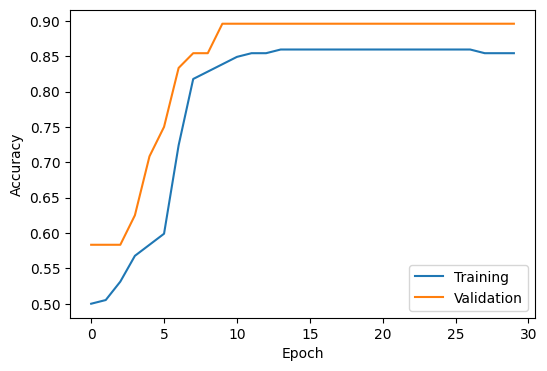

In [18]:
plt.figure(figsize=(6,4))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [19]:
ulasan = [
"Barang sangat bagus",
"Kualitas jelek",
"Sangat puas",
"Barang rusak",
"Harga sesuai kualitas",
"Tidak sesuai deskripsi",
"Pelayanan ramah",
"Pengiriman cepat",
"Kecewa sekali",
"Recommended"
]

label = [
1,
0,
1,
0,
1,
0,
1,
1,
0,
1
]

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik:",
      len(tfidf.get_feature_names_out()))

print(tfidf.get_feature_names_out())

Jumlah kata unik: 18
['bagus' 'barang' 'cepat' 'deskripsi' 'harga' 'jelek' 'kecewa' 'kualitas'
 'pelayanan' 'pengiriman' 'puas' 'ramah' 'recommended' 'rusak' 'sangat'
 'sekali' 'sesuai' 'tidak']


In [21]:
from sklearn.linear_model import LogisticRegression

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

model_sentimen = LogisticRegression()

model_sentimen.fit(
    Xt_train,
    yt_train
)

akurasi = model_sentimen.score(
    Xt_test,
    yt_test
)

print("Akurasi:", akurasi)

Akurasi: 0.0


In [11]:
kalimat = [
"Pelayanan sangat memuaskan"
]

pred = model_sentimen.predict(
    tfidf.transform(kalimat)
)

print(pred)

print("Positif" if pred[0]==1 else "Negatif")

[1]
Positif
